In [1]:
import numpy as np
import scipy.special



In [2]:
def modmc1(m, q, x):
    return scipy.special.mathieu_modcem1(m, q, x)
def modmc2(m, q, x):
    return scipy.special.mathieu_modcem2(m, q, x)

def modms1(m, q, x):
    return scipy.special.mathieu_modsem1(m, q, x)
def modms2(m, q, x):
    return scipy.special.mathieu_modsem2(m, q, x)

def mathieu_a(m, q):
    return scipy.special.mathieu_a(m, q)

def mathieu_b(m, q):
    return scipy.special.mathieu_b(m, q)



In [3]:
# Round trip modmc1
NN = 100
v = np.linspace(2,5,NN)
h = 1e-5
tol = 1e-3
MM = 100
qs = np.logspace(-4,2,10)



error = []

for m in range(MM):
    for q in qs:
        fm3 = modmc1(m, q, v - 3 * h)[1]
        fm2 = modmc1(m, q, v - 2 * h)[1]
        fm1 = modmc1(m, q, v - h)[1]
        fp1 = modmc1(m, q, v + h)[1]
        fp2 = modmc1(m, q, v + 2 * h)[1]
        fp3 = modmc1(m, q, v + 3 * h)[1]

        ydd = -fm3/60 + 3*fm2/20 - 3*fm1/4 + 3*fp1/4 - 3*fp2/20 + fp3/60

        [y,yd] = modmc1(m,q,v)
        a = mathieu_a(m,q)

        r = ydd/(h) - (a - 2 * q * np.cosh(2*v)) * y
        stddev = np.std(r)
        l2norm = np.linalg.norm(y, ord=2)

        error.append(stddev / l2norm)
        if not np.isclose(stddev / l2norm , 0, atol=tol):
            
            print(f'm = {m}, q = {q}, error = {stddev / l2norm}')




m = 8, q = 0.0001, error = 0.0028581107096091653
m = 9, q = 0.0001, error = 0.0048121431292248015
m = 10, q = 0.0001, error = 3.4309614795724888
m = 10, q = 0.00046415888336127773, error = 0.0014757385767948882
m = 11, q = 0.0001, error = 5.583649632929073
m = 11, q = 0.00046415888336127773, error = 0.0031120831673311306
m = 12, q = 0.0001, error = 5283.196482291527
m = 12, q = 0.00046415888336127773, error = 0.5028534483364083
m = 13, q = 0.0001, error = 9024.125462282436
m = 13, q = 0.00046415888336127773, error = 1.0149887001158138
m = 14, q = 0.0001, error = 120152.3194236104
m = 14, q = 0.00046415888336127773, error = 215.5604087328531
m = 14, q = 0.002154434690031882, error = 0.008095681767727103
m = 15, q = 0.0001, error = 116842.38030197125
m = 15, q = 0.00046415888336127773, error = 468.7451226433609
m = 15, q = 0.002154434690031882, error = 0.008624954272593322
m = 16, q = 0.0001, error = 92814.94489580915
m = 16, q = 0.00046415888336127773, error = 108967.54223811562
m = 16,

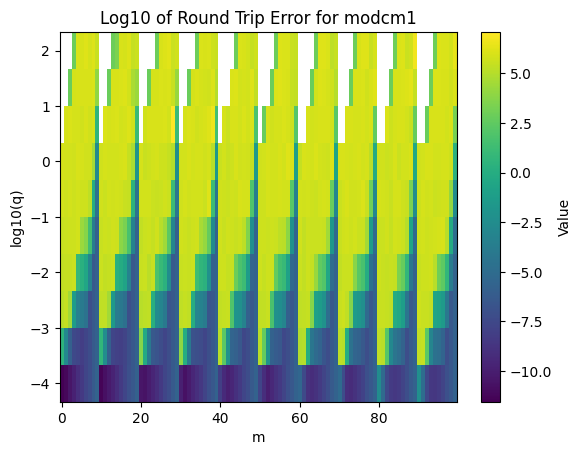

In [4]:
import matplotlib.pyplot as plt

M, Q = np.meshgrid(range(MM), qs)

error_array = np.array(error).reshape(M.shape)


fig, ax = plt.subplots()
im = ax.pcolormesh(range(MM), np.log10(qs), np.log10(error_array), cmap='viridis')

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Value')

ax.set_title("Log10 of Round Trip Error for modcm1")
ax.set_xlabel("m")
ax.set_ylabel("log10(q)")

plt.show()

In [5]:
# Round trip modmc2

NN = 100
v = np.linspace(2,5,NN)
h = 1e-5
tol = 1e-3
MM = 100
qs = np.logspace(-4,4,10)
error = []
for m in range(MM):
    for q in qs:
        fm3 = modmc2(m, q, v - 3 * h)[1]
        fm2 = modmc2(m, q, v - 2 * h)[1]
        fm1 = modmc2(m, q, v - h)[1]
        fp1 = modmc2(m, q, v + h)[1]
        fp2 = modmc2(m, q, v + 2 * h)[1]
        fp3 = modmc2(m, q, v + 3 * h)[1]

        ydd = -fm3/60 + 3*fm2/20 - 3*fm1/4 + 3*fp1/4 - 3*fp2/20 + fp3/60

        [y,yd] = modmc2(m,q,v)
        a = mathieu_a(m,q)

        r = ydd/(h) - (a - 2 * q * np.cosh(2*v)) * y
        stddev = np.std(r)
        l2norm = np.linalg.norm(y, ord=2)

        error.append(stddev / l2norm)
        if not np.isclose(stddev / l2norm , 0, atol=tol):
            print(f'm = {m}, q = {q}, error = {stddev / l2norm}')



m = 0, q = 10000.0, error = nan
m = 1, q = 10000.0, error = nan
m = 2, q = 10000.0, error = nan
m = 3, q = 10000.0, error = nan
m = 4, q = 10000.0, error = nan
m = 5, q = 10000.0, error = nan
m = 6, q = 10000.0, error = nan
m = 7, q = 10000.0, error = nan
m = 8, q = 10000.0, error = nan
m = 9, q = 10000.0, error = nan
m = 10, q = 10000.0, error = nan
m = 11, q = 10000.0, error = nan
m = 12, q = 10000.0, error = nan
m = 13, q = 10000.0, error = nan
m = 14, q = 10000.0, error = nan
m = 15, q = 10000.0, error = nan
m = 16, q = 10000.0, error = nan
m = 17, q = 10000.0, error = nan
m = 18, q = 10000.0, error = nan
m = 19, q = 10000.0, error = nan
m = 20, q = 10000.0, error = nan
m = 21, q = 10000.0, error = nan
m = 22, q = 10000.0, error = nan
m = 23, q = 10000.0, error = nan
m = 24, q = 10000.0, error = nan
m = 25, q = 10000.0, error = nan
m = 26, q = 10000.0, error = nan
m = 27, q = 10000.0, error = nan
m = 28, q = 10000.0, error = nan
m = 29, q = 10000.0, error = nan
m = 30, q = 10000.0,

/Users/aliamy/Desktop/Mathieu/mathieu/lib/python3.13/site-packages/numpy/linalg/_linalg.py:2791: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
/Users/aliamy/Desktop/Mathieu/mathieu/lib/python3.13/site-packages/numpy/_core/_methods.py:193: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/var/folders/wt/zm67l5653nz4gjnqr_vxcvnc0000gn/T/ipykernel_13038/2281184117.py:28: RuntimeWarning: invalid value encountered in scalar divide
  error.append(stddev / l2norm)
/var/folders/wt/zm67l5653nz4gjnqr_vxcvnc0000gn/T/ipykernel_13038/2281184117.py:29: RuntimeWarning: invalid value encountered in scalar divide
  if not np.isclose(stddev / l2norm , 0, atol=tol):
/var/folders/wt/zm67l5653nz4gjnqr_vxcvnc0000gn/T/ipykernel_13038/2281184117.py:30: RuntimeWarning: invalid value encountered in scalar divide
  print(f'm = {m}, q = {q}, error = {stddev / l2norm}')


/var/folders/wt/zm67l5653nz4gjnqr_vxcvnc0000gn/T/ipykernel_13038/3496676092.py:8: RuntimeWarning: divide by zero encountered in log10
  im = ax.pcolormesh(range(MM), np.log10(qs), np.log10(error_array), cmap='viridis')


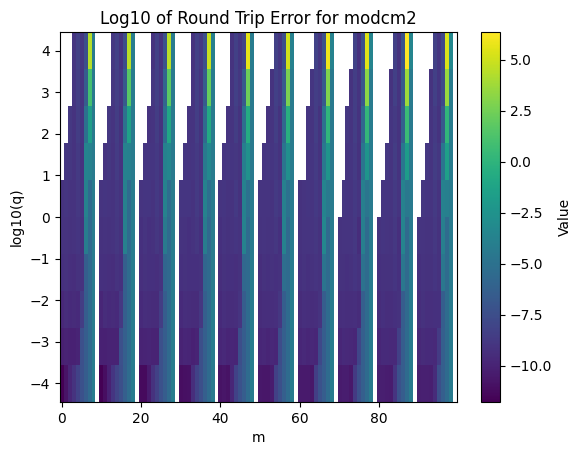

In [6]:
import matplotlib.pyplot as plt

M, Q = np.meshgrid(range(MM), qs)

error_array = np.array(error).reshape(M.shape)

fig, ax = plt.subplots()
im = ax.pcolormesh(range(MM), np.log10(qs), np.log10(error_array), cmap='viridis')

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Value')

ax.set_title("Log10 of Round Trip Error for modcm2")
ax.set_xlabel("m")
ax.set_ylabel("log10(q)")

plt.show()

In [7]:
import math
# Round trip modms1

NN = 100
v = np.linspace(2,5,NN)
h = 1e-5
tol = 1e-3
MM = 100
qs = np.logspace(-4,2,10)
error = []

for m in range(1, MM):
    for q in qs:
        fm3 = modms1(m, q, v - 3 * h)[1]
        fm2 = modms1(m, q, v - 2 * h)[1]
        fm1 = modms1(m, q, v - h)[1]
        fp1 = modms1(m, q, v + h)[1]
        fp2 = modms1(m, q, v + 2 * h)[1]
        fp3 = modms1(m, q, v + 3 * h)[1]

        ydd = -fm3/60 + 3*fm2/20 - 3*fm1/4 + 3*fp1/4 - 3*fp2/20 + fp3/60

        [y,yd] = modms1(m,q,v)
        a = mathieu_b(m,q)

        r = ydd/(h) - (a - 2 * q * np.cosh(2*v)) * y
        stddev = np.std(r)
        l2norm = np.linalg.norm(y, ord=2)

        
        error.append(stddev / l2norm)
        if not np.isclose(stddev / l2norm , 0, atol=tol):
            print(f'm = {m}, q = {q}, error = {stddev / l2norm}')



m = 6, q = 0.0001, error = 0.07678702425511283
m = 8, q = 0.0001, error = 5.572634314060848
m = 8, q = 0.00046415888336127773, error = 0.019699804333847368
m = 9, q = 0.0001, error = 0.005128824494986062
m = 10, q = 0.0001, error = 7.750086449923529
m = 10, q = 0.00046415888336127773, error = 1.185460186547874
m = 11, q = 0.0001, error = 5.660049552326087
m = 11, q = 0.00046415888336127773, error = 0.0030777540237578818
m = 12, q = 0.0001, error = 11.319006659503325
m = 12, q = 0.00046415888336127773, error = 10.728541137411195
m = 12, q = 0.002154434690031882, error = 0.08932675852691395
m = 13, q = 0.0001, error = 9828.721525171648
m = 13, q = 0.00046415888336127773, error = 0.9889983976752988
m = 14, q = 0.0001, error = 15.559709489063838
m = 14, q = 0.00046415888336127773, error = 14.929857092108152
m = 14, q = 0.002154434690031882, error = 7.511256459264916
m = 15, q = 0.0001, error = 177106.76513033878
m = 15, q = 0.00046415888336127773, error = 421.0491077750599
m = 15, q = 0.00

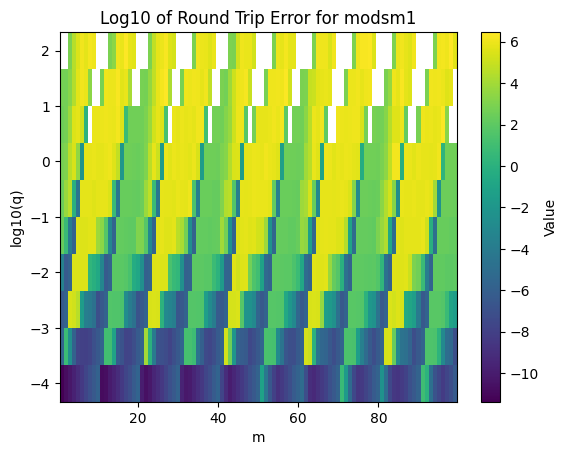

In [8]:
import matplotlib.pyplot as plt

M, Q = np.meshgrid(range(1,MM), qs)

error_array = np.array(error).reshape(M.shape)


fig, ax = plt.subplots()
im = ax.pcolormesh(range(1, MM), np.log10(qs), np.log10(error_array), cmap='viridis')

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Value')

ax.set_title("Log10 of Round Trip Error for modsm1")
ax.set_xlabel("m")
ax.set_ylabel("log10(q)")

plt.show()

In [9]:
# Round trip modms2

NN = 100
v = np.linspace(2,5,NN)
h = 1e-5
tol = 1e-3
MM = 100
qs = np.logspace(-4,2,10)
error = []

for m in range(1, MM):
    for q in qs:
        fm3 = modms2(m, q, v - 3 * h)[1]
        fm2 = modms2(m, q, v - 2 * h)[1]
        fm1 = modms2(m, q, v - h)[1]
        fp1 = modms2(m, q, v + h)[1]
        fp2 = modms2(m, q, v + 2 * h)[1]
        fp3 = modms2(m, q, v + 3 * h)[1]

        ydd = -fm3/60 + 3*fm2/20 - 3*fm1/4 + 3*fp1/4 - 3*fp2/20 + fp3/60

        [y,yd] = modms2(m,q,v)
        a = mathieu_b(m,q)

        r = ydd/(h) - (a - 2 * q * np.cosh(2*v)) * y
        stddev = np.std(r)
        l2norm = np.linalg.norm(y, ord=2)
        error.append(stddev / l2norm)

        if not np.isclose(stddev / l2norm , 0, atol=tol):
            print(f'm = {m}, q = {q}, error = {stddev / l2norm}')



m = 57, q = 100.0, error = 0.001160910850822136
m = 58, q = 0.0001, error = nan
m = 58, q = 100.0, error = 0.0013042833153668078
m = 59, q = 0.0001, error = nan
m = 59, q = 100.0, error = 0.0015884916022128033
m = 60, q = 0.0001, error = nan
m = 60, q = 100.0, error = 0.002699373718603582
m = 61, q = 0.0001, error = nan
m = 61, q = 100.0, error = 0.009663907804564673
m = 62, q = 0.0001, error = nan
m = 62, q = 100.0, error = 0.015507090489739611
m = 63, q = 0.0001, error = nan
m = 63, q = 100.0, error = 0.03924901805150817
m = 64, q = 0.0001, error = nan
m = 64, q = 100.0, error = 0.02752069982707612
m = 65, q = 0.0001, error = nan
m = 65, q = 100.0, error = 0.0870002596829817
m = 66, q = 0.0001, error = nan
m = 66, q = 0.00046415888336127773, error = nan
m = 66, q = 100.0, error = 0.36887477912316113
m = 67, q = 0.0001, error = nan
m = 67, q = 0.00046415888336127773, error = nan
m = 67, q = 100.0, error = 0.2236305767789093
m = 68, q = 0.0001, error = nan
m = 68, q = 0.000464158883361

/var/folders/wt/zm67l5653nz4gjnqr_vxcvnc0000gn/T/ipykernel_13038/3774711314.py:28: RuntimeWarning: invalid value encountered in scalar divide
  error.append(stddev / l2norm)
/var/folders/wt/zm67l5653nz4gjnqr_vxcvnc0000gn/T/ipykernel_13038/3774711314.py:30: RuntimeWarning: invalid value encountered in scalar divide
  if not np.isclose(stddev / l2norm , 0, atol=tol):
/var/folders/wt/zm67l5653nz4gjnqr_vxcvnc0000gn/T/ipykernel_13038/3774711314.py:31: RuntimeWarning: invalid value encountered in scalar divide
  print(f'm = {m}, q = {q}, error = {stddev / l2norm}')
/Users/aliamy/Desktop/Mathieu/mathieu/lib/python3.13/site-packages/numpy/_core/_methods.py:204: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


/var/folders/wt/zm67l5653nz4gjnqr_vxcvnc0000gn/T/ipykernel_13038/2763452502.py:9: RuntimeWarning: divide by zero encountered in log10
  im = ax.pcolormesh(range(1, MM), np.log10(qs), np.log10(error_array), cmap='viridis')


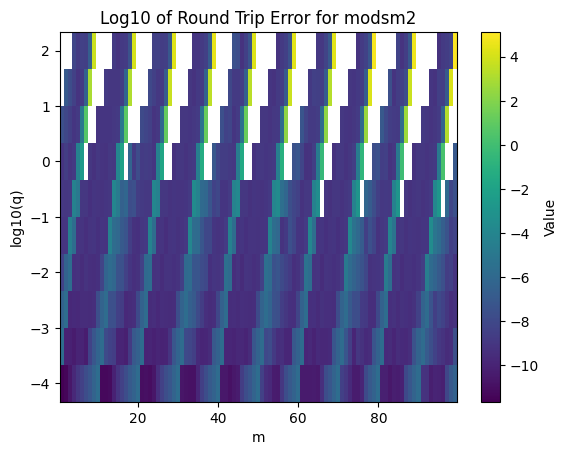

In [10]:
import matplotlib.pyplot as plt

M, Q = np.meshgrid(range(1,MM), qs)

error_array = np.array(error).reshape(M.shape)


fig, ax = plt.subplots()
im = ax.pcolormesh(range(1, MM), np.log10(qs), np.log10(error_array), cmap='viridis')

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Value')

ax.set_title("Log10 of Round Trip Error for modsm2")
ax.set_xlabel("m")
ax.set_ylabel("log10(q)")

plt.show()